In [33]:
# 1. Imports
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib


In [34]:
# 2. File paths (change if needed)
EMO_TRAIN = "train.txt"
EMO_VAL   = "val.txt"
EMO_TEST  = "test.txt"
SENT_CSV  = "sentiment.csv"

# helper: check files exist
for f in [EMO_TRAIN, EMO_VAL, EMO_TEST, SENT_CSV]:
    if not os.path.exists(f):
        print(f"Note: file not found (may be okay if you intend to change path): {f}")


Note: file not found (may be okay if you intend to change path): sentiment.csv


In [35]:
# 3. Utility: detect separator for a .txt file by sampling first lines
def detect_sep(filepath, candidates=[';', '\t', '|', ',', ':::']):
    # Return first candidate that produces 2+ columns consistently
    sample = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as fh:
        for i, line in enumerate(fh):
            if i >= 50: break
            sample.append(line.strip())
    for sep in candidates:
        counts = [len(line.split(sep)) for line in sample if line]
        # we want most lines to split into 2 parts (text,label)
        if len(counts) == 0:
            continue
        mode_count = max(set(counts), key=counts.count)
        # prefer separators that split into exactly 2 fields most of the time
        if mode_count == 2:
            return sep
    # fallback: try tab or space
    return '\t'


In [36]:
# 4. Load emotion .txt files into DataFrame (fixed for pandas on_bad_lines)
def load_emotion_txt(train_path, val_path, test_path):
    # detect sep from train (or try val/test)
    for p in [train_path, val_path, test_path]:
        if os.path.exists(p):
            sep = detect_sep(p)
            break
    else:
        raise FileNotFoundError("None of the emotion files found.")
    # read with that sep, fallback to tab if fails
    def read_file(p):
        try:
            df = pd.read_csv(
                p,
                sep=sep,
                header=None,
                names=['text','label'],
                engine='python',
                encoding='utf-8',
                on_bad_lines='skip'
            )
        except Exception:
            # try splitting first tab then fallback to manual parsing
            try:
                df = pd.read_csv(
                    p,
                    sep='\t',
                    header=None,
                    names=['text','label'],
                    engine='python',
                    encoding='utf-8',
                    on_bad_lines='skip'
                )
            except Exception:
                # final fallback: read as single column and parse manually below
                df = pd.read_csv(p, header=None, names=['raw'], encoding='utf-8', engine='python', on_bad_lines='skip')

        # If only one column ('raw'), split manually by common separators
        if 'raw' in df.columns or df.shape[1] == 1:
            series = df.iloc[:,0].astype(str)
            texts = []
            labels = []
            for s in series:
                s = s.strip()
                if not s:
                    continue
                found = False
                for ssep in [';', '\t', '|', ':::']:
                    if ssep in s:
                        parts = s.rsplit(ssep, 1)
                        texts.append(parts[0].strip())
                        labels.append(parts[1].strip())
                        found = True
                        break
                if not found:
                    # try splitting by last space as last resort
                    parts = s.rsplit(' ', 1)
                    if len(parts) == 2:
                        texts.append(parts[0].strip()); labels.append(parts[1].strip())
                    else:
                        # unknown label — keep text and assign 'unknown'
                        texts.append(s); labels.append("unknown")
            df = pd.DataFrame({'text': texts, 'label': labels})

        # normalize
        df = df.dropna(subset=['text'])
        df['label'] = df['label'].astype(str).str.strip()
        df['text'] = df['text'].astype(str)
        return df

    dfs = []
    for path in [train_path, val_path, test_path]:
        if os.path.exists(path):
            dfi = read_file(path)
            dfi['split_source'] = os.path.basename(path)
            dfs.append(dfi)
    if len(dfs) == 0:
        raise FileNotFoundError("No emotion files loaded.")
    all_df = pd.concat(dfs, ignore_index=True)
    all_df = all_df[all_df['text'].str.strip().str.len() > 0].reset_index(drop=True)
    return all_df

# load emotion dataset (call this after defining the function)
emotion_df = load_emotion_txt(EMO_TRAIN, EMO_VAL, EMO_TEST)
print("Emotion dataset loaded. shape:", emotion_df.shape)
print("Emotion labels (sample):", emotion_df['label'].unique()[:30])
emotion_df.head()


Emotion dataset loaded. shape: (20000, 3)
Emotion labels (sample): ['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']


,text,label,split_source
0,i didnt feel humiliated,sadness,train.txt
1,i can go from feeling so hopeless to so damned...,sadness,train.txt
2,im grabbing a minute to post i feel greedy wrong,anger,train.txt
3,i am ever feeling nostalgic about the fireplac...,love,train.txt
4,i am feeling grouchy,anger,train.txt


In [37]:
import os

# See where your notebook is running
print("📂 Current working directory:", os.getcwd())

# List all files in it
print("\n📄 Files in this folder:")
for f in os.listdir():
    print(" -", f)


📂 Current working directory: e:\MANIT Hackathone\New folder

📄 Files in this folder:
 - 1.ipynb
 - archive
 - archive sentiment
 - archive sentiment.zip
 - archive sentiments
 - archive sentiments.zip
 - archive.zip
 - saved_models
 - sentiments.csv
 - test.txt
 - train.txt
 - val.txt


In [17]:
!pip install chardet



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\pcs88\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [21]:
import sys
!{sys.executable} -m pip install chardet


  Using cached chardet-5.2.0-py3-none-any.whl.metadata (3.4 kB)
Using cached chardet-5.2.0-py3-none-any.whl (199 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import chardet
print("✅ chardet installed successfully!")


✅ chardet installed successfully!


In [38]:
# STEP 5 — FINAL version (handles any encoding issue automatically)

import os
import pandas as pd

# 🔧 Try to import chardet, auto-install if missing
try:
    import chardet
except ImportError:
    import sys
    !{sys.executable} -m pip install chardet
    import chardet


def detect_encoding(file_path, nbytes=100000):
    """Detect file encoding using chardet."""
    with open(file_path, 'rb') as f:
        raw = f.read(nbytes)
    result = chardet.detect(raw)
    return result['encoding']


def load_sentiment_csv(path):
    """Load sentiment CSV robustly, handling all encodings."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found: {path}")

    # 1️⃣ Detect encoding
    encoding_used = detect_encoding(path)
    print(f"🔍 Detected encoding: {encoding_used}")

    # 2️⃣ Try reading file safely
    try:
        df = pd.read_csv(path, encoding=encoding_used, engine='python', on_bad_lines='skip')
    except UnicodeDecodeError:
        print("⚠️ Fallback to ISO-8859-1 due to decoding error")
        df = pd.read_csv(path, encoding='ISO-8859-1', engine='python', on_bad_lines='skip')

    print(f"✅ Loaded sentiment dataset: {os.path.basename(path)}")
    print(f"📊 Shape: {df.shape}")

    # 3️⃣ Auto-detect text + label columns
    text_cols = [c for c in df.columns if c.lower() in ['text','sentence','tweet','content','review','message','comment']]
    label_cols = [c for c in df.columns if c.lower() in ['label','sentiment','target','class','polarity']]

    if len(text_cols) == 0:  # fallback: first string column
        for c in df.columns:
            if df[c].dtype == object:
                text_cols = [c]
                break

    if len(label_cols) == 0:  # fallback: numeric/small unique values
        for c in df.columns:
            if df[c].dtype != object and df[c].nunique() <= 10:
                label_cols = [c]
                break
        if len(label_cols) == 0:
            for c in df.columns:
                if df[c].nunique() <= 10 and c not in text_cols:
                    label_cols = [c]
                    break

    if len(text_cols) == 0 or len(label_cols) == 0:
        raise ValueError("Couldn't detect text/label columns. Please rename them manually.")

    df = df.rename(columns={text_cols[0]: 'text', label_cols[0]: 'label'})
    df = df[['text','label']].dropna(subset=['text']).reset_index(drop=True)
    df['text'] = df['text'].astype(str)
    df['label'] = df['label'].astype(str).str.strip()

    print("🏷️ Unique labels:", df['label'].unique()[:20])
    return df


# --- 👇 Load your sentiment dataset here ---
SENT_CSV = "sentiments.csv"
sentiment_df = load_sentiment_csv(SENT_CSV)

print("\n✅ Sample rows:")
display(sentiment_df.head())


🔍 Detected encoding: utf-8
✅ Loaded sentiment dataset: sentiments.csv
📊 Shape: (27481, 4)
🏷️ Unique labels: ['neutral' 'negative' 'positive']

✅ Sample rows:


,text,label
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [42]:
print(sentiment_df.columns.tolist())


['text', 'label', 'text_clean']


In [43]:
sentiment_df['label'].value_counts()


Series([], Name: count, dtype: int64)

In [44]:
sentiment_df.head()


,text,label,text_clean


In [45]:
print(sentiment_df.columns.tolist())
print(sentiment_df.shape)


['text', 'label', 'text_clean']
(0, 3)


In [46]:
import pandas as pd

# --- Step 1: Load original sentiment CSV ---
sentiment_df = pd.read_csv("sentiments.csv", encoding="utf-8")  # use your correct filename

# --- Step 2: Keep only necessary columns ---
sentiment_df = sentiment_df[['text', 'sentiment']].dropna()

# --- Step 3: Rename for consistency ---
sentiment_df.rename(columns={'sentiment': 'label'}, inplace=True)

# --- Step 4: Clean text ---
def clean_text(text):
    import re, html
    if pd.isna(text):
        return ""
    t = str(text)
    t = html.unescape(t)
    t = t.lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'@\w+', '', t)
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

sentiment_df['text_clean'] = sentiment_df['text'].apply(clean_text)

# --- Step 5: Check balance ---
print(sentiment_df['label'].value_counts())
print(sentiment_df.shape)
sentiment_df.head()


label
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64
(27480, 3)


,text,label,text_clean
0,"I`d have responded, if I were going",neutral,i d have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego
2,my boss is bullying me...,negative,my boss is bullying me
3,what interview! leave me alone,negative,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldn t they put them on the rele...


✅ Text cleaning completed for both datasets.
label
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64
label
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

🚀 Training model for: Emotion Detection
Dataset shape: (20000, 4)

✅ Accuracy: 0.8900

📋 Classification Report:
              precision    recall  f1-score   support

       anger       0.93      0.83      0.88       542
        fear       0.90      0.84      0.87       475
         joy       0.86      0.97      0.91      1352
        love       0.87      0.73      0.79       328
     sadness       0.91      0.94      0.92      1159
    surprise       0.88      0.58      0.70       144

    accuracy                           0.89      4000
   macro avg       0.89      0.81      0.84      4000
weighted avg       0.89      0.89      0.89      4000



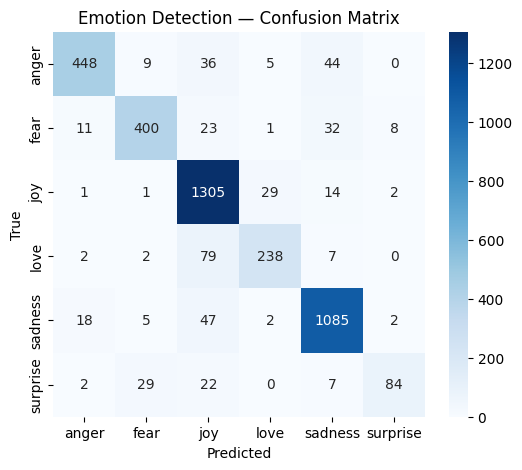


🚀 Training model for: Sentiment Analysis
Dataset shape: (27480, 3)

✅ Accuracy: 0.6890

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.60      0.66      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.78      0.69      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



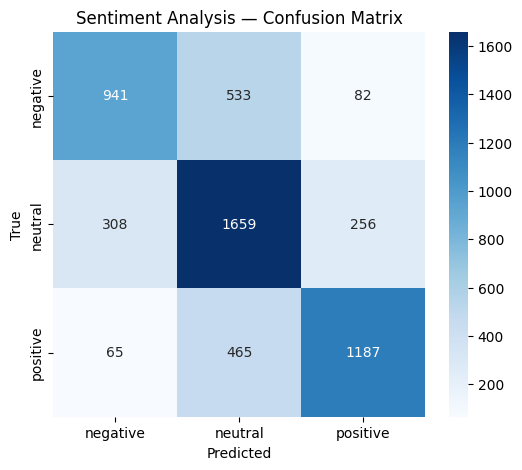

In [48]:
# STEP 6 — CLEANING + TRAINING + EVALUATION

import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ------------------ 1️⃣ Cleaning Function ------------------

def clean_text(text):
    if pd.isna(text):
        return ""
    t = str(text)
    t = html.unescape(t)
    t = t.lower()
    t = re.sub(r'http\S+', '', t)     # remove URLs
    t = re.sub(r'@\w+', '', t)        # remove @mentions
    t = re.sub(r'[^a-z0-9\s]', ' ', t) # remove special chars
    t = re.sub(r'\s+', ' ', t).strip()
    return t


# ------------------ 2️⃣ Apply Cleaning ------------------

try:
    emotion_df['text_clean'] = emotion_df['text'].apply(clean_text)
    sentiment_df['text_clean'] = sentiment_df['text'].apply(clean_text)
    print("✅ Text cleaning completed for both datasets.")
except Exception as e:
    print("⚠️ Error in cleaning:", e)


# Normalize numeric sentiment labels to text
# Use the correct column name from your dataset
# ✅ If your dataset already has textual labels (positive/neutral/negative)
# just keep them as is
sentiment_df['label'] = sentiment_df['label'].astype(str)
sentiment_df = sentiment_df.dropna(subset=['label']).reset_index(drop=True)
print(sentiment_df['label'].value_counts())


# If your dataset already has textual labels like "positive", "neutral", "negative",
# there’s no need to remap numeric codes
sentiment_df = sentiment_df.dropna(subset=['label']).reset_index(drop=True)

sentiment_df = sentiment_df.dropna(subset=['label']).reset_index(drop=True)

print(sentiment_df['label'].value_counts())


# ------------------ 3️⃣ Training Function ------------------

def train_and_evaluate(df, text_col='text_clean', label_col='label', task_name="Task"):
    """
    Train a Logistic Regression model using TF-IDF features and show results
    """
    print(f"\n🚀 Training model for: {task_name}")
    print(f"Dataset shape: {df.shape}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col], df[label_col], test_size=0.2, random_state=42, stratify=df[label_col]
    )

    # TF-IDF vectorizer
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Logistic Regression Model
    model = LogisticRegression(max_iter=200)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Accuracy and Report
    acc = accuracy_score(y_test, y_pred)
    print(f"\n✅ Accuracy: {acc:.4f}\n")
    print("📋 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"{task_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return model, vectorizer


# ------------------ 4️⃣ Train Both Models ------------------

try:
    emotion_model, emotion_vectorizer = train_and_evaluate(emotion_df, "text_clean", "label", "Emotion Detection")
except Exception as e:
    print("⚠️ Skipping Emotion dataset:", e)

try:
    sentiment_model, sentiment_vectorizer = train_and_evaluate(sentiment_df, "text_clean", "label", "Sentiment Analysis")
except Exception as e:
    print("⚠️ Skipping Sentiment dataset:", e)


In [49]:
# STEP 7 — SAVE TRAINED MODELS
import joblib
import os

# Create a folder to store models
os.makedirs("saved_models", exist_ok=True)

try:
    # Emotion model + vectorizer
    joblib.dump(emotion_model, "saved_models/emotion_model.pkl")
    joblib.dump(emotion_vectorizer, "saved_models/emotion_vectorizer.pkl")
    print("✅ Emotion model and vectorizer saved successfully.")
except Exception as e:
    print("⚠️ Emotion model not saved:", e)

try:
    # Sentiment model + vectorizer
    joblib.dump(sentiment_model, "saved_models/sentiment_model.pkl")
    joblib.dump(sentiment_vectorizer, "saved_models/sentiment_vectorizer.pkl")
    print("✅ Sentiment model and vectorizer saved successfully.")
except Exception as e:
    print("⚠️ Sentiment model not saved:", e)


✅ Emotion model and vectorizer saved successfully.
✅ Sentiment model and vectorizer saved successfully.


In [50]:
# STEP 8 — LOAD AND TEST PREDICTIONS

import joblib

# Load saved models and vectorizers
emotion_model = joblib.load("saved_models/emotion_model.pkl")
emotion_vectorizer = joblib.load("saved_models/emotion_vectorizer.pkl")

sentiment_model = joblib.load("saved_models/sentiment_model.pkl")
sentiment_vectorizer = joblib.load("saved_models/sentiment_vectorizer.pkl")

# ------------- Prediction Functions -------------

def predict_emotion(text):
    """
    Predicts emotion label for given text
    """
    cleaned = clean_text(text)
    vec = emotion_vectorizer.transform([cleaned])
    pred = emotion_model.predict(vec)[0]
    return pred

def predict_sentiment(text):
    """
    Predicts sentiment (positive/negative/neutral) for given text
    """
    cleaned = clean_text(text)
    vec = sentiment_vectorizer.transform([cleaned])
    pred = sentiment_model.predict(vec)[0]
    return pred


# ------------- Test with Sample Text -------------

sample_texts = [
    "I’m so happy and excited today!",
    "This is the worst day ever...",
    "I feel calm and relaxed right now.",
    "I'm really scared about tomorrow."
]

print("🔍 Emotion & Sentiment Predictions:\n")
for txt in sample_texts:
    emo = predict_emotion(txt)
    sen = predict_sentiment(txt)
    print(f"Text: {txt}")
    print(f" → Emotion: {emo}")
    print(f" → Sentiment: {sen}")
    print("-" * 50)


🔍 Emotion & Sentiment Predictions:

Text: I’m so happy and excited today!
 → Emotion: joy
 → Sentiment: positive
--------------------------------------------------
Text: This is the worst day ever...
 → Emotion: sadness
 → Sentiment: negative
--------------------------------------------------
Text: I feel calm and relaxed right now.
 → Emotion: joy
 → Sentiment: negative
--------------------------------------------------
Text: I'm really scared about tomorrow.
 → Emotion: fear
 → Sentiment: negative
--------------------------------------------------


In [51]:
sentiment_df['label'].value_counts().head()


label
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64